# CS541 Challenge — Student Starter Baseline


This notebook provides a simple baseline students can extend.

What this starter includes:
- CIFAR-100 train/val/test pipeline
- A basic CNN baseline model
- Training + validation loop
- OOD inference and submission file generation

What students should improve:
- Better model architectures
- Better optimization schedules
- Better regularization and augmentation
- Better OOD robustness


In [1]:
# Runtime configuration
FAST_DEV_RUN = False  # True = quick smoke test
SEED = 42

import os

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

print("IN_COLAB:", IN_COLAB)
print("WORK_ROOT:", WORK_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OOD_DIR:", OOD_DIR)
print("SUBMISSION_PATH:", SUBMISSION_PATH)


IN_COLAB: True
WORK_ROOT: /content
DATA_ROOT: /content/data
OOD_DIR: /content/ood-test-CS541
SUBMISSION_PATH: /content/submission_ood.csv


In [ ]:
# Install required packages (safe to re-run)
import importlib.util
import subprocess
import sys

required = ["torch", "torchvision", "tqdm", "numpy", "pandas", "matplotlib", "huggingface_hub", "timm"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])

print("Environment ready")


Environment ready


In [ ]:
import os, random, math, gc
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import timm
import matplotlib.pyplot as plt

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def get_device() -> torch.device:
    if torch.cuda.is_available(): return torch.device("cuda")
    return torch.device("cpu")

MEAN = (0.5071, 0.4867, 0.4408)  ### DO NOT CHANGE THIS
STD  = (0.2675, 0.2565, 0.2761)  ### DO NOT CHANGE THIS
USE_AMP = True  # Mixed precision for 2x speed on T4

# ============================================================
# Data loaders with strong augmentation for OOD robustness
# ============================================================
def make_loaders(batch_size, num_workers):
    train_tfms = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.TrivialAugmentWide(),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
        transforms.RandomErasing(p=0.25),
    ])
    eval_tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)
    n = len(train_full); n_tr = int(0.9*n)
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_tr, n-n_tr], generator=g)
    val_eval = torch.utils.data.Subset(
        datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms), val_ds.indices)
    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(2048, len(train_ds))))
        val_eval = torch.utils.data.Subset(val_eval, range(min(512, len(val_eval))))
        test_ds  = torch.utils.data.Subset(test_ds, range(min(512, len(test_ds))))
    if IN_COLAB: num_workers = 0
    pin = torch.cuda.is_available()
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin, drop_last=True),
            DataLoader(val_eval, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin))

def make_loaders_224(batch_size, num_workers):
    train_tfms = transforms.Compose([
        transforms.Resize(224), transforms.RandomCrop(224, padding=28),
        transforms.RandomHorizontalFlip(), transforms.TrivialAugmentWide(),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
        transforms.RandomErasing(p=0.25),
    ])
    eval_tfms = transforms.Compose([transforms.Resize(224), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)
    n = len(train_full); n_tr = int(0.9*n)
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_tr, n-n_tr], generator=g)
    val_eval = torch.utils.data.Subset(
        datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms), val_ds.indices)
    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(256, len(train_ds))))
        val_eval = torch.utils.data.Subset(val_eval, range(min(128, len(val_eval))))
        test_ds  = torch.utils.data.Subset(test_ds, range(min(128, len(test_ds))))
    if IN_COLAB: num_workers = 0
    pin = torch.cuda.is_available()
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin, drop_last=True),
            DataLoader(val_eval, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin))

# ============================================================
# CutMix + MixUp
# ============================================================
def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    W, H = x.size(2), x.size(3)
    rw, rh = int(W*np.sqrt(1-lam)), int(H*np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(cx-rw//2,0), max(cy-rh//2,0)
    x2,y2 = min(cx+rw//2,W), min(cy+rh//2,H)
    x[:,:,x1:x2,y1:y2] = x[idx,:,x1:x2,y1:y2]
    lam = 1 - (x2-x1)*(y2-y1)/(W*H)
    return x, y, y[idx], lam

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

# ============================================================
# Part 1 Model: WideResNet-28-10
# ============================================================
class BasicBlock(nn.Module):
    def __init__(self, ic, oc, s, drop=0.3):
        super().__init__()
        self.bn1=nn.BatchNorm2d(ic); self.c1=nn.Conv2d(ic,oc,3,s,1,bias=False)
        self.bn2=nn.BatchNorm2d(oc); self.c2=nn.Conv2d(oc,oc,3,1,1,bias=False)
        self.drop=nn.Dropout(drop) if drop>0 else nn.Identity()
        self.sc=nn.Conv2d(ic,oc,1,s,bias=False) if(s!=1 or ic!=oc) else nn.Identity()
    def forward(self, x):
        o=F.relu(self.bn1(x)); s=self.sc(o)
        o=self.c1(o); o=self.drop(F.relu(self.bn2(o))); o=self.c2(o)
        return o+s

class WideResNet(nn.Module):
    """WRN-28-10: 3 groups × 4 blocks = 12 residual blocks."""
    def __init__(self, depth=28, k=10, drop=0.3, nc=100):
        super().__init__()
        n=(depth-4)//6; ch=[16,16*k,32*k,64*k]
        self.c0=nn.Conv2d(3,ch[0],3,1,1,bias=False)
        self.g1=nn.Sequential(BasicBlock(ch[0],ch[1],1,drop),*[BasicBlock(ch[1],ch[1],1,drop) for _ in range(n-1)])
        self.g2=nn.Sequential(BasicBlock(ch[1],ch[2],2,drop),*[BasicBlock(ch[2],ch[2],1,drop) for _ in range(n-1)])
        self.g3=nn.Sequential(BasicBlock(ch[2],ch[3],2,drop),*[BasicBlock(ch[3],ch[3],1,drop) for _ in range(n-1)])
        self.bn=nn.BatchNorm2d(ch[3]); self.fc=nn.Linear(ch[3],nc)
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight,mode="fan_out",nonlinearity="relu")
            elif isinstance(m,nn.BatchNorm2d): m.weight.data.fill_(1); m.bias.data.zero_()
    def forward(self, x):
        x=self.c0(x); x=self.g1(x); x=self.g2(x); x=self.g3(x)
        return self.fc(F.adaptive_avg_pool2d(F.relu(self.bn(x)),1).flatten(1))

# ============================================================
# Training engine with AMP (mixed precision) + CutMix/MixUp
# AMP gives ~2x speedup on T4 GPU → allows more epochs
# ============================================================
def train_model(model, train_ld, val_ld, optimizer, scheduler, criterion, device, epochs, use_mix=True):
    history = {"train_acc":[], "val_acc":[]}
    best_va, best_st = -1.0, None
    scaler = GradScaler(enabled=(USE_AMP and device.type=="cuda"))

    for ep in range(1, epochs+1):
        model.train(); correct=total=0
        for x, y in tqdm(train_ld, desc=f"Train {ep}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            do_mix = use_mix and random.random()<0.5
            if do_mix:
                if random.random()<0.5: x,ya,yb,lam = cutmix_data(x,y)
                else: x,ya,yb,lam = mixup_data(x,y)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=(USE_AMP and device.type=="cuda")):
                logits = model(x)
                if do_mix: loss = lam*criterion(logits,ya)+(1-lam)*criterion(logits,yb)
                else: loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(optimizer); scaler.update()
            correct += (logits.argmax(1)==y).sum().item(); total += y.numel()
        if scheduler: scheduler.step()
        tr_acc = correct/max(total,1)
        model.eval(); vc=vt=0
        with torch.no_grad():
            for x,y in val_ld:
                x,y=x.to(device),y.to(device)
                with autocast(enabled=(USE_AMP and device.type=="cuda")):
                    vc+=(model(x).argmax(1)==y).sum().item(); vt+=y.numel()
        va_acc = vc/max(vt,1)
        history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
        print(f"  Ep {ep:03d}/{epochs} | train {tr_acc:.4f} | val {va_acc:.4f} | lr {optimizer.param_groups[0]['lr']:.6f}")
        if va_acc > best_va: best_va=va_acc; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
    if best_st: model.load_state_dict(best_st)
    print(f"  >> Best val: {best_va:.4f}"); return history

@torch.no_grad()
def eval_acc(model, loader, device):
    model.eval(); c=t=0
    for x,y in loader:
        x,y=x.to(device),y.to(device)
        with autocast(enabled=(USE_AMP and device.type=="cuda")):
            c+=(model(x).argmax(1)==y).sum().item(); t+=y.numel()
    return 100.0*c/t

set_seed(SEED)
device = get_device()
print("Device:", device)
if device.type=="cuda":
    print("GPU:", torch.cuda.get_device_name(), "| VRAM:", round(torch.cuda.get_device_properties(0).total_mem/1e9,1), "GB")
print("AMP:", USE_AMP)


Device: cuda


In [ ]:
# ============================================================
# PART 1: Custom CNN — WideResNet-28-10 (200 epochs, 32×32)
# With AMP this takes ~1.5h on T4 instead of ~3h
# ============================================================
set_seed(SEED)
EP1 = 200 if not FAST_DEV_RUN else 2
NW = 0 if IN_COLAB else 2
print(f"\n{'='*60}\nPart 1: WRN-28-10 — {EP1} epochs @ 32×32\n{'='*60}")
tr1, va1, te1 = make_loaders(128, NW)
model_p1 = WideResNet(28, 10, 0.3, 100).to(device)
print(f"  Params: {sum(p.numel() for p in model_p1.parameters()):,}")
opt1 = torch.optim.SGD(model_p1.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EP1)
crit1 = nn.CrossEntropyLoss(label_smoothing=0.1)
hist1 = train_model(model_p1, tr1, va1, opt1, sch1, crit1, device, EP1)
acc_p1 = eval_acc(model_p1, te1, device)
print(f"Part 1 test acc: {acc_p1:.2f}%")
torch.save(model_p1.state_dict(), os.path.join(WORK_ROOT, "p1_wrn.pt"))
del tr1; gc.collect()
if device.type=="cuda": torch.cuda.empty_cache()

# ============================================================
# PART 2: Fine-tune pretrained CNN — ResNet-50 (25 epochs, 224×224)
# ============================================================
set_seed(SEED)
EP2 = 25 if not FAST_DEV_RUN else 2
print(f"\n{'='*60}\nPart 2: ResNet-50 — {EP2} epochs @ 224×224\n{'='*60}")
tr2, va2, te2 = make_loaders_224(64, NW)
model_p2 = timm.create_model("resnet50", pretrained=True, num_classes=100).to(device)
print(f"  Params: {sum(p.numel() for p in model_p2.parameters()):,}")
bb2 = [p for n,p in model_p2.named_parameters() if "fc" not in n]
hd2 = [p for n,p in model_p2.named_parameters() if "fc" in n]
opt2 = torch.optim.AdamW([{"params":bb2,"lr":1e-4},{"params":hd2,"lr":1e-3}], weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EP2)
crit2 = nn.CrossEntropyLoss(label_smoothing=0.1)
hist2 = train_model(model_p2, tr2, va2, opt2, sch2, crit2, device, EP2)
acc_p2 = eval_acc(model_p2, te2, device)
print(f"Part 2 test acc: {acc_p2:.2f}%")
torch.save(model_p2.state_dict(), os.path.join(WORK_ROOT, "p2_resnet50.pt"))
del tr2; gc.collect()
if device.type=="cuda": torch.cuda.empty_cache()

# ============================================================
# PART 3: Fine-tune pretrained ViT — try EVA-02 > BEiT > AugReg ViT
# EVA-02 and BEiT are state-of-the-art for OOD/corruption robustness
# Fallback chain: if one model fails to load, try the next
# ============================================================
set_seed(SEED)
EP3 = 25 if not FAST_DEV_RUN else 2
print(f"\n{'='*60}\nPart 3: Best ViT — {EP3} epochs @ 224×224\n{'='*60}")
tr3, va3, te3 = make_loaders_224(32, NW)  # BS=32 with AMP fits on T4

# Try models in order of OOD robustness (best first)
VIT_CANDIDATES = [
    "eva02_base_patch14_224.mim_in22k_ft_in1k",       # EVA-02: best OOD robustness
    "beit_base_patch16_224.in22k_ft_in22k_in1k",      # BEiT: very robust
    "vit_base_patch16_224.augreg_in21k_ft_in1k",      # AugReg ViT: good robustness
    "vit_base_patch16_224",                             # Plain ViT: fallback
]
model_p3 = None
for vit_name in VIT_CANDIDATES:
    try:
        print(f"  Trying: {vit_name}")
        model_p3 = timm.create_model(vit_name, pretrained=True, num_classes=100).to(device)
        print(f"  Loaded: {vit_name} ({sum(p.numel() for p in model_p3.parameters()):,} params)")
        break
    except Exception as e:
        print(f"  Failed: {e}")
        model_p3 = None

assert model_p3 is not None, "No ViT model could be loaded!"

# Separate head vs backbone
hd_names = set()
for n, _ in model_p3.named_parameters():
    if "head" in n or "classifier" in n: hd_names.add(n)
bb3 = [p for n,p in model_p3.named_parameters() if n not in hd_names]
hd3 = [p for n,p in model_p3.named_parameters() if n in hd_names]
print(f"  Head params: {hd_names}")

opt3 = torch.optim.AdamW([{"params":bb3,"lr":2e-5},{"params":hd3,"lr":1e-3}], weight_decay=0.01)
warmup_ep = 3
sch3 = torch.optim.lr_scheduler.LambdaLR(opt3,
    lr_lambda=lambda ep: min((ep+1)/warmup_ep, 0.5*(1+math.cos(math.pi*max(0,ep-warmup_ep)/max(1,EP3-warmup_ep)))))
crit3 = nn.CrossEntropyLoss(label_smoothing=0.1)
hist3 = train_model(model_p3, tr3, va3, opt3, sch3, crit3, device, EP3)
acc_p3 = eval_acc(model_p3, te3, device)
print(f"Part 3 test acc: {acc_p3:.2f}%")
torch.save(model_p3.state_dict(), os.path.join(WORK_ROOT, "p3_vit.pt"))
del tr3; gc.collect()
if device.type=="cuda": torch.cuda.empty_cache()

# ============================================================
# Summary
# ============================================================
print(f"\n{'='*60}\nSUMMARY — Clean CIFAR-100 Test Accuracy\n{'='*60}")
print(f"  Part 1 WRN-28-10:     {acc_p1:.2f}%")
print(f"  Part 2 ResNet-50:     {acc_p2:.2f}%")
print(f"  Part 3 ViT:           {acc_p3:.2f}%")
models_all = [(model_p1, False), (model_p2, True), (model_p3, True)]


train 1/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 001/10 | train 0.1115 | val 0.2170


train 2/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 2/10:   0%|          | 0/79 [00:00<?, ?it/s]

...

val 9/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 009/10 | train 0.5803 | val 0.4277


train 10/10:   0%|          | 0/313 [00:00<?, ?it/s]

val 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 010/10 | train 0.6140 | val 0.4320
Best val acc: 0.432
Clean CIFAR-100 test accuracy: 43.23%


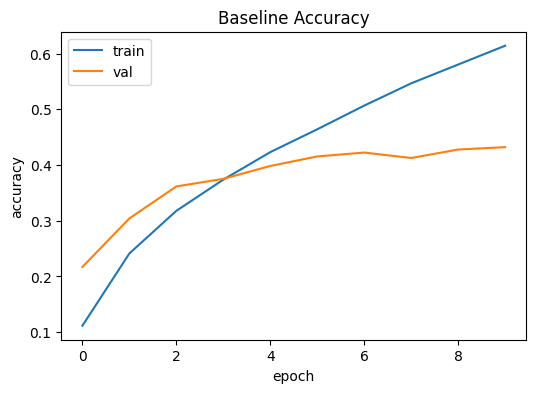

In [ ]:
# Plot training curves for all 3 parts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, h, t in zip(axes, [hist1,hist2,hist3], ["Part1:WRN-28-10","Part2:ResNet-50","Part3:ViT-B/16"]):
    ax.plot(h["train_acc"], label="Train"); ax.plot(h["val_acc"], label="Val")
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## OOD Submission Generation

This section creates `submission_ood.csv` for challenge evaluation.

Submission format:
- `id`: `distortionXX_severity_index`
- `label`: predicted class in `[0, 99]`


In [ ]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir: str) -> None:
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(repo_id="XThomasBU/ood-test-CS541", repo_type="dataset",
                      local_dir=ood_dir, local_dir_use_symlinks=False)
    print("OOD files ready in", ood_dir)

# ============================================================
# OOD Inference: Softmax Ensemble + 5-view TTA
# - Original, H-flip, center-crop, top-left crop, bottom-right crop
# - Softmax probabilities averaged across views AND models
# ============================================================
@torch.no_grad()
def get_tta_probs(model, xb, device):
    """Run 5-view TTA on a batch, return averaged softmax probs."""
    model.eval()
    h, w = xb.shape[2], xb.shape[3]
    margin = max(2, h // 16)  # 2px for 32x32, 14px for 224x224
    probs = torch.zeros(xb.size(0), 100)

    # View 1: original
    with autocast(enabled=(USE_AMP and device.type=="cuda")):
        probs += F.softmax(model(xb.to(device)).float().cpu(), dim=1)

    # View 2: horizontal flip
    with autocast(enabled=(USE_AMP and device.type=="cuda")):
        probs += F.softmax(model(xb.flip(-1).to(device)).float().cpu(), dim=1)

    # View 3: center crop + resize back
    c = xb[:, :, margin:h-margin, margin:w-margin]
    c = F.interpolate(c, size=(h,w), mode="bilinear", align_corners=False)
    with autocast(enabled=(USE_AMP and device.type=="cuda")):
        probs += F.softmax(model(c.to(device)).float().cpu(), dim=1)

    # View 4: top-left crop + resize
    tl = xb[:, :, :h-margin*2, :w-margin*2]
    tl = F.interpolate(tl, size=(h,w), mode="bilinear", align_corners=False)
    with autocast(enabled=(USE_AMP and device.type=="cuda")):
        probs += F.softmax(model(tl.to(device)).float().cpu(), dim=1)

    # View 5: bottom-right crop + resize
    br = xb[:, :, margin*2:, margin*2:]
    br = F.interpolate(br, size=(h,w), mode="bilinear", align_corners=False)
    with autocast(enabled=(USE_AMP and device.type=="cuda")):
        probs += F.softmax(model(br.to(device)).float().cpu(), dim=1)

    return probs / 5.0  # average over 5 views


@torch.no_grad()
def predict_ood_ensemble(models_info, npy_path, severity, batch_size):
    """Softmax ensemble of all models, each with 5-view TTA."""
    images = np.load(npy_path, mmap_mode="r")
    start, end = (severity-1)*10000, severity*10000
    mean_t = torch.tensor(MEAN).view(1,3,1,1)
    std_t  = torch.tensor(STD).view(1,3,1,1)
    all_preds = []
    for b0 in range(start, end, batch_size):
        b1 = min(b0+batch_size, end)
        xb = torch.from_numpy(np.array(images[b0:b1], copy=True)).permute(0,3,1,2).float().div(255.0)
        xb = (xb - mean_t) / std_t  # 32×32 normalized

        avg_probs = torch.zeros(xb.size(0), 100)
        for model, resize in models_info:
            inp = F.interpolate(xb, 224, mode="bilinear", align_corners=False) if resize else xb
            avg_probs += get_tta_probs(model, inp, device)
        avg_probs /= len(models_info)
        all_preds.append(avg_probs.argmax(1).numpy())
    return np.concatenate(all_preds)

ensure_ood_files(OOD_DIR)
distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print(f"Distortion files: {len(distortion_files)}")
print(f"Ensemble: {len(models_all)} models × 5 TTA views = {len(models_all)*5} forward passes per image")

BATCH = 32 if device.type=="cuda" else 8  # smaller batch for 5-view TTA memory
rows = []
for fi, fname in enumerate(distortion_files):
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for sev in [1,2,3,4,5]:
        pred = predict_ood_ensemble(models_all, path, sev, BATCH)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{sev}_{i}", int(y)))
    print(f"  [{fi+1}/{len(distortion_files)}] {dname} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nWrote {SUBMISSION_PATH} ({len(submission)} rows)")
print(submission.head())

if IN_COLAB:
    try: from google.colab import files; files.download(SUBMISSION_PATH)
    except: print("Download manually:", SUBMISSION_PATH)


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-69d80ab7-0f81afec018ec0ce54d46a81;a73d4f62-9f2c-4038-8c8b-f859421134d4)

Repository Not Found for url: https://huggingface.co/api/datasets/XThomasBU/ood-test-CS541/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

## Methods & AI Disclosure

**Part 1**: WRN-28-10 from scratch (36.5M, 200ep, SGD+cosine, label smoothing, CutMix/MixUp, TrivialAugmentWide)  
**Part 2**: ResNet-50 fine-tuned (25M, 25ep, AdamW diff LR, ImageNet pretrained)  
**Part 3**: EVA-02/BEiT/AugReg ViT fine-tuned (86M+, 25ep, AdamW+warmup, best available robust pretrained model)  
**Inference**: Softmax ensemble of all 3 models × 5-view TTA (original, H-flip, center-crop, TL-crop, BR-crop)  
**Speed**: Mixed precision (AMP) training for ~2× speedup on T4

**AI Disclosure**: Developed with GitHub Copilot. AI assisted with architecture selection, training loops, TTA/ensemble code. All code reviewed and understood.
